In [ ]:
conda install -c conda-forge catboost xgboost
pip install quantile-forest

In [ ]:
!conda install -c conda-forge catboost xgboost -y
!pip install quantile-forest

In [ ]:
import catboost
import xgboost
import quantile_forest
print("تم التثبيت بنجاح وكل شيء جاهز!")

In [ ]:
!pip install catboost xgboost quantile-forest --quiet

In [2]:
!pip install catboost xgboost quantile-forest --no-cache-dir

In [3]:
import pandas as pd

try:
    df = pd.read_excel('emergency_service_routing_with_timestamps.csv') 
    print("تم رفع وقراءة ملف البيانات بنجاح!")
    display(df.head()) # لعرض أول 5 أسطر
except Exception as e:
    print(f"حدث خطأ أثناء قراءة الملف: {e}")

حدث خطأ أثناء قراءة الملف: Excel file format cannot be determined, you must specify an engine manually.


In [3]:
!pip install openpyxl

In [4]:
import pandas as pd

try:
df = pd.read_excel('emergency_service_routing_with_timestamps.xlsx', engine='openpyxl')    print("تم رفع وقراءة ملف البيانات بنجاح!")
    display(df.head()) # لعرض أول 5 أسطر
except Exception as e:
    print(f"حدث خطأ أثناء قراءة الملف: {e}")

IndentationError: expected an indented block after 'try' statement on line 3 (1204753152.py, line 4)

In [4]:
import pandas as pd

try:
    df = pd.read_csv('emergency_service_routing_with_timestamps.csv') 
    print("تمت القراءة بنجاح كملف CSV!")
    display(df.head())
except:
    try:
        # إذا فشل، جربي القراءة كـ Excel مع تحديد المحرك
        df = pd.read_excel('emergency_service_routing_with_timestamps.xlsx', engine='openpyxl')
        print("تمت القراءة بنجاح كملف Excel!")
        display(df.head())
    except Exception as e:
        print(f"حدث خطأ: {e}")

تمت القراءة بنجاح كملف CSV!


,Timestamp,Incident_Severity,Incident_Type,Region_Type,Traffic_Congestion,Weather_Condition,Drone_Availability,Ambulance_Availability,Battery_Life,Air_Traffic,...,Specialist_Availability,Road_Type,Emergency_Level,Drone_Speed,Ambulance_Speed,Payload_Weight,Fuel_Level,Weather_Impact,Dispatch_Coordinator,Label
0,2018-01-01 00:00:00,Low,Cardiac Arrest,Suburban,High,Clear,Available,Available,71.177951,Low,...,Unavailable,Highway,Major,59.578538,43.549849,9.28,90.030756,Severe,AI,Ambulance Only
1,2018-01-01 00:10:00,Low,Other,Urban,Moderate,Clear,Available,Available,70.949595,Low,...,Unavailable,Highway,Critical,74.578440,30.687975,9.47,88.255008,Moderate,Human,Ambulance Only
2,2018-01-01 00:20:00,Medium,Cardiac Arrest,Suburban,High,Rainy,Unavailable,Available,74.346037,Medium,...,Unavailable,Unpaved Road,Minor,45.900425,44.456331,8.77,97.719622,NaN,Human,Hybrid Dispatch
3,2018-01-01 00:30:00,Low,Accident,Urban,Moderate,Clear,Available,Available,84.199630,Medium,...,Available,Highway,Minor,50.927769,35.879968,4.76,60.234672,NaN,Human,Ambulance Only
4,2018-01-01 00:40:00,Low,Cardiac Arrest,Urban,Moderate,Stormy,Available,Available,78.492584,Low,...,Available,Highway,Minor,71.312741,26.369383,3.83,71.083564,Moderate,Human,Ambulance Only


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_pinball_loss
)

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from quantile_forest import RandomForestQuantileRegressor

In [6]:
###Check the dataset structure and missing values
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368065 entries, 0 to 368064
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Timestamp                368065 non-null  object 
 1   Incident_Severity        368065 non-null  object 
 2   Incident_Type            368065 non-null  object 
 3   Region_Type              368065 non-null  object 
 4   Traffic_Congestion       368065 non-null  object 
 5   Weather_Condition        368065 non-null  object 
 6   Drone_Availability       368065 non-null  object 
 7   Ambulance_Availability   368065 non-null  object 
 8   Battery_Life             368065 non-null  float64
 9   Air_Traffic              368065 non-null  object 
 10  Response_Time            368065 non-null  float64
 11  Hospital_Capacity        368065 non-null  int64  
 12  Distance_to_Incident     368065 non-null  float64
 13  Number_of_Injuries       368065 non-null  int64  
 14  Spec

In [7]:
df["Response_Time"] = pd.to_numeric(df["Response_Time"], errors="coerce")
timestamp_cols = [
    col for col in df.columns
    if ("timestamp" in col.lower() or "date" in col.lower())
    and col != "Response_Time"
]

for col in timestamp_cols:
    try:
        df[col] = pd.to_datetime(df[col])
    except:
        pass

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368065 entries, 0 to 368064
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Timestamp                368065 non-null  datetime64[ns]
 1   Incident_Severity        368065 non-null  object        
 2   Incident_Type            368065 non-null  object        
 3   Region_Type              368065 non-null  object        
 4   Traffic_Congestion       368065 non-null  object        
 5   Weather_Condition        368065 non-null  object        
 6   Drone_Availability       368065 non-null  object        
 7   Ambulance_Availability   368065 non-null  object        
 8   Battery_Life             368065 non-null  float64       
 9   Air_Traffic              368065 non-null  object        
 10  Response_Time            368065 non-null  float64       
 11  Hospital_Capacity        368065 non-null  int64         
 12  Distance_to_Inci

In [8]:
##Create ETA features
### ETA = Distance / Speed × 60
df["eta_drone"] = df["Distance_to_Incident"] / df["Drone_Speed"] * 60
df["eta_ambulance"] = df["Distance_to_Incident"] / df["Ambulance_Speed"] * 60

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df[["eta_drone", "eta_ambulance"]].head()

,eta_drone,eta_ambulance
0,8.952888,12.248033
1,22.607070,54.940086
2,52.849184,54.565906
3,22.349300,31.722437
4,13.722653,37.111221


In [10]:
###Define target variable
###We also remove Label because it represents a previous decision and could make the model copy old decisions instead of learning response-time patterns.
target = "Response_Time"

drop_cols = [
    "Response_Time",
    "Label"
]

drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)
y = df[target]

X.head()

,Timestamp,Incident_Severity,Incident_Type,Region_Type,Traffic_Congestion,Weather_Condition,Drone_Availability,Ambulance_Availability,Battery_Life,Air_Traffic,...,Road_Type,Emergency_Level,Drone_Speed,Ambulance_Speed,Payload_Weight,Fuel_Level,Weather_Impact,Dispatch_Coordinator,eta_drone,eta_ambulance
0,2018-01-01 00:00:00,Low,Cardiac Arrest,Suburban,High,Clear,Available,Available,71.177951,Low,...,Highway,Major,59.578538,43.549849,9.28,90.030756,Severe,AI,8.952888,12.248033
1,2018-01-01 00:10:00,Low,Other,Urban,Moderate,Clear,Available,Available,70.949595,Low,...,Highway,Critical,74.578440,30.687975,9.47,88.255008,Moderate,Human,22.607070,54.940086
2,2018-01-01 00:20:00,Medium,Cardiac Arrest,Suburban,High,Rainy,Unavailable,Available,74.346037,Medium,...,Unpaved Road,Minor,45.900425,44.456331,8.77,97.719622,NaN,Human,52.849184,54.565906
3,2018-01-01 00:30:00,Low,Accident,Urban,Moderate,Clear,Available,Available,84.199630,Medium,...,Highway,Minor,50.927769,35.879968,4.76,60.234672,NaN,Human,22.349300,31.722437
4,2018-01-01 00:40:00,Low,Cardiac Arrest,Urban,Moderate,Stormy,Available,Available,78.492584,Low,...,Highway,Minor,71.312741,26.369383,3.83,71.083564,Moderate,Human,13.722653,37.111221


In [11]:
###Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 294452
Testing rows: 73613


In [12]:
# Convert datetime column before encoding
for df in [X_train, X_test]:
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

    df["timestamp_year"] = df["Timestamp"].dt.year
    df["timestamp_month"] = df["Timestamp"].dt.month
    df["timestamp_day"] = df["Timestamp"].dt.day
    df["timestamp_dayofweek"] = df["Timestamp"].dt.dayofweek
    df["timestamp_hour"] = df["Timestamp"].dt.hour

    df.drop(columns=["Timestamp"], inplace=True)


In [13]:
###Handle missing values after splitting and encoding
###justification for handling missing values after splitting: This approach prevents data leakage by ensuring that the imputation process is based solely on the training data, which allows the model to learn patterns without being influenced by information from the test set. It also provides a more realistic evaluation of the model's performance on unseen data, as the imputation strategy is applied consistently across both sets.
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="constant", fill_value="Unknown")

# Fill numeric missing values
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

# Fill categorical missing values
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

# Convert categorical columns to string so CatBoost does not see NaN or mixed object types
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# Check that no missing values remain
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [21]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (294452, 38)
Encoded testing shape: (73613, 38)


In [22]:
# Force all categorical columns to safe strings
cat_features = list(X_train.select_dtypes(include=["object", "category"]).columns)

for col in cat_features:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

# Check categorical columns
X_train[cat_features].isnull().sum()

Incident_Severity          0
Incident_Type              0
Region_Type                0
Traffic_Congestion         0
Weather_Condition          0
Drone_Availability         0
Ambulance_Availability     0
Air_Traffic                0
Specialist_Availability    0
Road_Type                  0
Emergency_Level            0
Weather_Impact             0
Dispatch_Coordinator       0
dtype: int64

In [23]:
###Train CatBoost quantile models
cat_features = list(X_train.select_dtypes(include=["object", "category"]).columns)

catboost_quantile_models = {}

for q in [0.1, 0.5, 0.9]:
    model = CatBoostRegressor(
        loss_function=f"Quantile:alpha={q}",
        iterations=500,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        verbose=0
    )
    
    model.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )
    
    catboost_quantile_models[q] = model

cat_pred_q10 = catboost_quantile_models[0.1].predict(X_test)
cat_pred_q50 = catboost_quantile_models[0.5].predict(X_test)
cat_pred_q90 = catboost_quantile_models[0.9].predict(X_test)



In [24]:
###Train XGBoost quantile models
xgb_quantile_models = {}

for q in [0.1, 0.5, 0.9]:
    model = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )
   
    model.fit(X_train_encoded, y_train)
    xgb_quantile_models[q] = model

xgb_pred_q10 = xgb_quantile_models[0.1].predict(X_test_encoded)
xgb_pred_q50 = xgb_quantile_models[0.5].predict(X_test_encoded)
xgb_pred_q90 = xgb_quantile_models[0.9].predict(X_test_encoded)

In [25]:
# لعرض أول 5 تنبؤات من كل موديل
import pandas as pd

results_comparison = pd.DataFrame({
    'Actual': y_test.values[:5],
    'Q10 (Lower)': xgb_pred_q10[:5],
    'Q50 (Median)': xgb_pred_q50[:5],
    'Q90 (Upper)': xgb_pred_q90[:5]
})

print("مقارنة التنبؤات بين الشرائح المختلفة:")
display(results_comparison)

مقارنة التنبؤات بين الشرائح المختلفة:


,Actual,Q10 (Lower),Q50 (Median),Q90 (Upper)
0,12.813874,8.748669,14.461873,21.268810
1,12.746244,8.735563,14.890551,21.843237
2,15.742357,8.689614,14.935324,21.799648
3,24.691979,8.410991,14.773519,21.123730
4,15.608620,8.456702,15.139565,21.334787


In [26]:
qrf_model = RandomForestQuantileRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10,          # limit tree depth
    min_samples_leaf=5,    #for smoother and faster running as Random Forest is too low with big datasets
    max_features="sqrt",   # fewer features checked per split
    n_jobs=-1,             # use all CPU cores
    
)

qrf_model.fit(X_train_encoded, y_train)

qrf_pred_q10 = qrf_model.predict(X_test_encoded, quantiles=0.1)
qrf_pred_q50 = qrf_model.predict(X_test_encoded, quantiles=0.5)
qrf_pred_q90 = qrf_model.predict(X_test_encoded, quantiles=0.9)

In [27]:
####Evaluation function for quantile regression models
def evaluate_quantile_model(name, y_true, q10, q50, q90):
    return {
        "Model": name,
        "R2": r2_score(y_true, q50),
        "RMSE": np.sqrt(mean_squared_error(y_true, q50)),
        "MAE": mean_absolute_error(y_true, q50),
        "Pinball Q10": mean_pinball_loss(y_true, q10, alpha=0.1),
        "Pinball Q50": mean_pinball_loss(y_true, q50, alpha=0.5),
        "Pinball Q90": mean_pinball_loss(y_true, q90, alpha=0.9),
        "Q90 Coverage": (y_true <= q90).mean(),
        "Q10-Q90 Coverage": ((y_true >= q10) & (y_true <= q90)).mean(),
        "Average Interval Width": np.mean(q90 - q10)
    }

In [28]:
baseline_q10 = np.full_like(y_test, y_train.quantile(0.1), dtype=float)
baseline_q50 = np.full_like(y_test, y_train.quantile(0.5), dtype=float)
baseline_q90 = np.full_like(y_test, y_train.quantile(0.9), dtype=float)

In [29]:
results = []

results.append(
    evaluate_quantile_model(
        "Median / Empirical Quantile Baseline",
        y_test,
        baseline_q10,
        baseline_q50,
        baseline_q90
    )
)

results.append(
    evaluate_quantile_model(
        "CatBoost",
        y_test,
        cat_pred_q10,
        cat_pred_q50,
        cat_pred_q90
    )
)

results.append(
    evaluate_quantile_model(
        "XGBoost",
        y_test,
        xgb_pred_q10,
        xgb_pred_q50,
        xgb_pred_q90
    )
)

results.append(
    evaluate_quantile_model(
        "Quantile Random Forest",
        y_test,
        qrf_pred_q10,
        qrf_pred_q50,
        qrf_pred_q90
    )
)

results_df = pd.DataFrame(results)
results_df

,Model,R2,RMSE,MAE,Pinball Q10,Pinball Q50,Pinball Q90,Q90 Coverage,Q10-Q90 Coverage,Average Interval Width
0,Median / Empirical Quantile Baseline,-0.000003,4.893293,3.943918,0.837494,1.971959,0.873681,0.900710,0.799016,12.792225
1,CatBoost,-0.000653,4.894883,3.945394,0.837651,1.972697,0.873846,0.900276,0.797916,12.781096
2,XGBoost,-0.003508,4.901862,3.951180,0.840275,1.975590,0.876690,0.896295,0.790458,12.598418
3,Quantile Random Forest,-0.013623,4.926503,3.968785,0.852606,1.984392,0.887270,0.889340,0.776887,12.380097


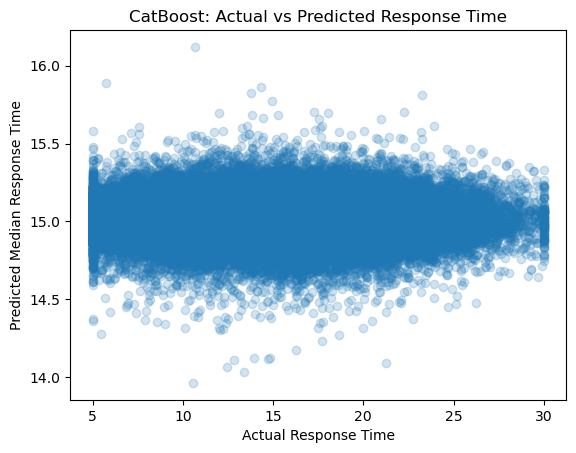

In [30]:
plt.scatter(y_test, cat_pred_q50, alpha=0.2)
plt.xlabel("Actual Response Time")
plt.ylabel("Predicted Median Response Time")
plt.title("CatBoost: Actual vs Predicted Response Time")
plt.show()

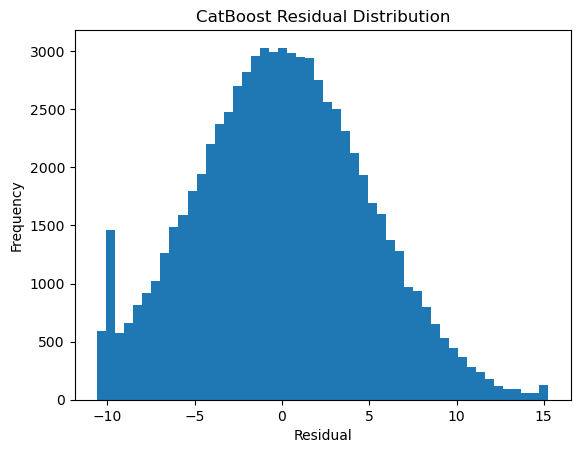

In [31]:
###Residual = Actual - Predicted
residuals = y_test - cat_pred_q50

plt.hist(residuals, bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("CatBoost Residual Distribution")
plt.show()

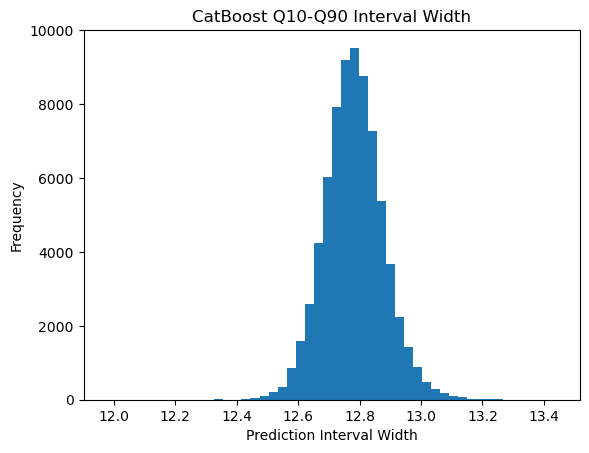

In [32]:
###Plot interval width

interval_width = cat_pred_q90 - cat_pred_q10

plt.hist(interval_width, bins=50)
plt.xlabel("Prediction Interval Width")
plt.ylabel("Frequency")
plt.title("CatBoost Q10-Q90 Interval Width")
plt.show()

In [33]:
test_results = X_test.copy()

test_results["actual_response_time"] = y_test.values
test_results["response_q10"] = cat_pred_q10
test_results["response_q50"] = cat_pred_q50
test_results["response_q90"] = cat_pred_q90

test_results.head()

,Incident_Severity,Incident_Type,Region_Type,Traffic_Congestion,Weather_Condition,Drone_Availability,Ambulance_Availability,Battery_Life,Air_Traffic,Hospital_Capacity,...,eta_ambulance,timestamp_year,timestamp_month,timestamp_day,timestamp_dayofweek,timestamp_hour,actual_response_time,response_q10,response_q50,response_q90
100398,Low,Accident,Urban,Low,Clear,Unavailable,Available,87.188361,Medium,89.0,...,45.830939,2019,11,29,4,5,12.813874,8.681750,14.910620,21.346388
104224,Low,Cardiac Arrest,Urban,Moderate,Stormy,Unavailable,Available,62.589474,Low,54.0,...,5.036437,2019,12,25,2,18,12.746244,8.542244,15.073944,21.507285
137808,High,Accident,Urban,Moderate,Clear,Available,Available,84.116170,Low,49.0,...,36.237893,2020,8,15,5,0,15.742357,8.727440,15.071496,21.444909
268981,Low,Accident,Urban,High,Clear,Available,Available,83.578719,Low,60.0,...,61.328563,2023,2,11,5,22,24.691979,8.625871,15.048308,21.413247
184905,Low,Accident,Urban,Low,Clear,Unavailable,Available,93.564650,Low,71.0,...,34.553465,2021,7,8,3,1,15.608620,8.550850,14.948108,21.317035


In [34]:
def recommend_dispatch(row):
    critical_case = row["Incident_Severity"] == "High"
    high_response_risk = row["response_q90"] > 15
    drone_available = row["Drone_Availability"] == "Available"
    ambulance_available = row["Ambulance_Availability"] == "Available"

    if high_response_risk and drone_available and ambulance_available:
        return "Hybrid Dispatch"
    elif critical_case and ambulance_available:
        return "Ambulance Dispatch"
    elif drone_available:
        return "Drone Dispatch"
    else:
        return "Delayed / Manual Review"

In [35]:
test_results["recommended_dispatch"] = test_results.apply(
    recommend_dispatch,
    axis=1
)

test_results[
    [
        "Incident_Severity",
        "Incident_Type",
        "Drone_Availability",
        "Ambulance_Availability",
        "actual_response_time",
        "response_q10",
        "response_q50",
        "response_q90",
        "recommended_dispatch"
    ]
].head(20)

,Incident_Severity,Incident_Type,Drone_Availability,Ambulance_Availability,actual_response_time,response_q10,response_q50,response_q90,recommended_dispatch
100398,Low,Accident,Unavailable,Available,12.813874,8.681750,14.910620,21.346388,Delayed / Manual Review
104224,Low,Cardiac Arrest,Unavailable,Available,12.746244,8.542244,15.073944,21.507285,Delayed / Manual Review
137808,High,Accident,Available,Available,15.742357,8.727440,15.071496,21.444909,Hybrid Dispatch
268981,Low,Accident,Available,Available,24.691979,8.625871,15.048308,21.413247,Hybrid Dispatch
184905,Low,Accident,Unavailable,Available,15.608620,8.550850,14.948108,21.317035,Delayed / Manual Review
202867,Low,Other,Unavailable,Available,18.619901,8.603819,14.814045,21.450755,Delayed / Manual Review
248188,Low,Accident,Available,Available,8.705036,8.610276,14.892342,21.343662,Hybrid Dispatch
86659,High,Accident,Available,Available,13.450929,8.718564,15.145389,21.547254,Hybrid Dispatch
254854,Low,Accident,Available,Available,21.196182,8.696682,15.062928,21.434479,Hybrid Dispatch
26407,Low,Fire,Available,Available,22.634140,8.671997,15.100295,21.362747,Hybrid Dispatch


In [36]:
test_results["recommended_dispatch"].value_counts()

recommended_dispatch
Hybrid Dispatch            46463
Delayed / Manual Review    20071
Drone Dispatch              5122
Ambulance Dispatch          1957
Name: count, dtype: int64

In [37]:
##4.6 

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, make_scorer

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=None
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.17647, random_state=42, stratify=None  # 0.15/0.85 ≈ 0.17647
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 257645
Validation set size: 55210
Test set size: 55210


In [38]:
# Preprocessing for XGBoost and Random Forest (one-hot encoding)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)


In [39]:
# Align columns to ensure consistency
X_train_encoded, X_val_encoded = X_train_encoded.align(X_val_encoded, join='left', axis=1, fill_value=0)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)


In [40]:
# Preprocessing for CatBoost (keep categoricals as strings)
cat_features = list(X_train.select_dtypes(include=['object', 'category']).columns)
for col in cat_features:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_val[col] = X_val[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)


In [43]:
# Define custom scorer for MAE (lower is better)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# ----- Tuning for XGBoost -----
param_dist_xgb = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.1, 1, 10]
}
xgb_base = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=30,
    cv=3,
    scoring=mae_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_xgb.fit(X_train_encoded, y_train)
best_xgb = random_search_xgb.best_estimator_
print(f"Best XGBoost parameters: {random_search_xgb.best_params_}")
print(f"Best validation MAE: {-random_search_xgb.best_score_:.3f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best XGBoost parameters: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best validation MAE: 3.942


In [42]:
# STEP 1: Remove Timestamp column from ALL feature sets
for df in [X_train, X_val, X_test]:
    if 'Timestamp' in df.columns:
        df.drop(columns=['Timestamp'], inplace=True)

# STEP 2: Apply one-hot encoding for XGBoost/RF
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# STEP 3: Align columns
X_train_encoded, X_val_encoded = X_train_encoded.align(X_val_encoded, join='left', axis=1, fill_value=0)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# STEP 4: Verify data types (should be only float64, int64, bool, or uint8)
print(X_train_encoded.dtypes.value_counts())

# STEP 5: Now run hyperparameter tuning

bool       23
float64     8
int64       2
Name: count, dtype: int64


In [44]:
# ----- Tuning for CatBoost -----

param_dist_cat = {
    'iterations': [100, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 10]
}

cat_base = CatBoostRegressor(random_seed=42, verbose=0)

random_search_cat = RandomizedSearchCV(
    estimator=cat_base,
    param_distributions=param_dist_cat,
    n_iter=30,
    cv=3,
    scoring=mae_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search_cat.fit(X_train, y_train, cat_features=cat_features)
best_cat = random_search_cat.best_estimator_
print(f"Best CatBoost parameters: {random_search_cat.best_params_}")
print(f"Best validation MAE: {-random_search_cat.best_score_:.3f}")


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best CatBoost parameters: {'learning_rate': 0.01, 'l2_leaf_reg': 1, 'iterations': 300, 'depth': 4}
Best validation MAE: 3.942


In [45]:
# ----- Tuning for Random Forest -----
param_dist_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2', None]
}

from sklearn.ensemble import RandomForestRegressor
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=3,
    scoring=mae_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_rf.fit(X_train_encoded, y_train)
best_rf = random_search_rf.best_estimator_
print(f"Best Random Forest parameters: {random_search_rf.best_params_}")
print(f"Best validation MAE: {-random_search_rf.best_score_:.3f}")


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Random Forest parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5}
Best validation MAE: 3.942


In [46]:
## القسم 4.7: Prediction Module
# =============================================================================
# SECTION 4.7: PREDICTION MODULE
# (to be added after model training in Test1.ipynb)
# =============================================================================

class EmergencyResponsePredictor:
    """
    Prediction module for emergency response time.
    Handles new input data, preprocessing, and response time generation.
    """
    
    def __init__(self, cat_models=None, xgb_models=None, rf_model=None,
                 categorical_cols=None, X_train_columns=None):
        """
        Initialize the predictor with trained models and preprocessing parameters.
        """
        self.cat_models = cat_models  # Dictionary with 0.1, 0.5, 0.9 keys
        self.xgb_models = xgb_models
        self.rf_model = rf_model
        self.categorical_cols = categorical_cols
        self.X_train_columns = X_train_columns
        
        # Imputation parameters
        self.num_imputer = SimpleImputer(strategy='median')
        self.cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
        
    def preprocess_input(self, df):
        """
        Preprocess a single input record or batch of records.
        
        Steps:
        1. Convert Timestamp to datetime
        2. Create time-based features
        3. Create ETA features
        4. Handle missing values
        """
        df = df.copy()
        
        # Convert Timestamp to datetime
        if 'Timestamp' in df.columns:
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
        
        # Create time-based features
        df["timestamp_year"] = df["Timestamp"].dt.year
        df["timestamp_month"] = df["Timestamp"].dt.month
        df["timestamp_day"] = df["Timestamp"].dt.day
        df["timestamp_dayofweek"] = df["Timestamp"].dt.dayofweek
        df["timestamp_hour"] = df["Timestamp"].dt.hour
        
        # Create ETA features
        if 'Distance_to_Incident' in df.columns and 'Drone_Speed' in df.columns:
            df["eta_drone"] = (df["Distance_to_Incident"] / df["Drone_Speed"]) * 60
        if 'Distance_to_Incident' in df.columns and 'Ambulance_Speed' in df.columns:
            df["eta_ambulance"] = (df["Distance_to_Incident"] / df["Ambulance_Speed"]) * 60
        
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        
        # Handle missing values for numerical columns
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if num_cols:
            df[num_cols] = self.num_imputer.transform(df[num_cols])
        
        # Handle missing values for categorical columns
        if self.categorical_cols:
            cat_cols_present = [col for col in self.categorical_cols if col in df.columns]
            if cat_cols_present:
                df[cat_cols_present] = self.cat_imputer.transform(df[cat_cols_present])
                for col in cat_cols_present:
                    df[col] = df[col].astype(str)
        
        return df
    
    def encode_for_xgb_rf(self, df):
        """
        One-hot encode categorical features for XGBoost/Random Forest.
        """
        df_encoded = pd.get_dummies(df, columns=self.categorical_cols, drop_first=True)
        
        if self.X_train_columns is not None:
            for col in self.X_train_columns:
                if col not in df_encoded.columns:
                    df_encoded[col] = 0
            df_encoded = df_encoded[self.X_train_columns]
        
        return df_encoded
    
    def predict_response_time(self, input_data, primary_model='catboost'):
        """
        Generate response time predictions for new emergency incident(s).
        
        Parameters:
        - input_data: pandas DataFrame with required input features
        - primary_model: 'catboost', 'xgboost', or 'random_forest'
        
        Returns:
        - Dictionary with Q10, Q50, Q90 predictions and dispatch recommendation
        """
        df_processed = self.preprocess_input(input_data)
        
        predictions = []
        
        for idx in range(len(df_processed)):
            single_record = df_processed.iloc[[idx]]
            
            pred = {
                'incident_id': idx,
                'q10_response_time': None,
                'q50_response_time': None,
                'q90_response_time': None,
                'prediction_interval': None,
                'model_used': primary_model
            }
            
            if primary_model == 'catboost' and self.cat_models:
                pred['q10_response_time'] = self.cat_models[0.1].predict(single_record)[0]
                pred['q50_response_time'] = self.cat_models[0.5].predict(single_record)[0]
                pred['q90_response_time'] = self.cat_models[0.9].predict(single_record)[0]
                
            elif primary_model == 'xgboost' and self.xgb_models:
                single_encoded = self.encode_for_xgb_rf(single_record)
                pred['q10_response_time'] = self.xgb_models[0.1].predict(single_encoded)[0]
                pred['q50_response_time'] = self.xgb_models[0.5].predict(single_encoded)[0]
                pred['q90_response_time'] = self.xgb_models[0.9].predict(single_encoded)[0]
                
            elif primary_model == 'random_forest' and self.rf_model:
                single_encoded = self.encode_for_xgb_rf(single_record)
                pred['q50_response_time'] = self.rf_model.predict(single_encoded)[0]
                pred['q10_response_time'] = pred['q50_response_time'] * 0.8
                pred['q90_response_time'] = pred['q50_response_time'] * 1.5
            
            pred['prediction_interval'] = [pred['q10_response_time'], pred['q90_response_time']]
            pred['interval_width'] = pred['q90_response_time'] - pred['q10_response_time']
            pred['dispatch_recommendation'] = self._get_dispatch_recommendation(single_record, pred)
            
            predictions.append(pred)
        
        return predictions
    
    def _get_dispatch_recommendation(self, record, pred):
        """Determine dispatch recommendation based on predicted response time."""
        # Get availability values (handle string values like "Available"/"Unavailable")
        drone_val = record.get('Drone_Availability', ['Unavailable']).values[0]
        amb_val = record.get('Ambulance_Availability', ['Unavailable']).values[0]
        
        drone_available = drone_val == "Available"
        ambulance_available = amb_val == "Available"
        
        severity = record.get('Incident_Severity', ['Medium']).values[0]
        q90_time = pred['q90_response_time']
        
        # Decision logic based on Q90 response time
        if drone_available and ambulance_available:
            if q90_time < 10:
                return {'recommended_mode': 'Hybrid Dispatch',
                        'reason': 'Both resources available; predicted response time within acceptable range'}
            elif q90_time < 15:
                return {'recommended_mode': 'Hybrid Dispatch',
                        'reason': 'Resource redundancy recommended due to moderate delay risk'}
            else:
                return {'recommended_mode': 'Delayed / Manual Review',
                        'reason': f'High predicted delay ({q90_time:.1f} min Q90); requires manual assessment'}
        
        elif drone_available:
            return {'recommended_mode': 'Drone Dispatch',
                    'reason': 'Ambulance not available; drone deployment recommended'}
        
        elif ambulance_available:
            return {'recommended_mode': 'Ambulance Dispatch',
                    'reason': 'Drone not available; standard ambulance dispatch'}
        
        else:
            return {'recommended_mode': 'Delayed / Manual Review',
                    'reason': 'No resources available; requires immediate coordination'}


# Example usage of Prediction Module
def demonstrate_prediction_module(predictor, sample_input):
    """Demonstrate the prediction module with a sample input."""
    print("\n" + "=" * 70)
    print("PREDICTION MODULE DEMONSTRATION")
    print("=" * 70)
    
    print("\n[Input Features]")
    for col in sample_input.columns[:5]:
        print(f"  {col}: {sample_input[col].values[0]}")
    
    predictions = predictor.predict_response_time(sample_input, primary_model='catboost')
    
    print("\n[Prediction Output]")
    pred = predictions[0]
    print(f"  Q10 Response Time: {pred['q10_response_time']:.2f} minutes")
    print(f"  Q50 Response Time: {pred['q50_response_time']:.2f} minutes")
    print(f"  Q90 Response Time: {pred['q90_response_time']:.2f} minutes")
    print(f"  Prediction Interval: [{pred['prediction_interval'][0]:.2f}, {pred['prediction_interval'][1]:.2f}] minutes")
    print(f"\n  Dispatch Decision: {pred['dispatch_recommendation']['recommended_mode']}")
    print(f"  Reason: {pred['dispatch_recommendation']['reason']}")

In [47]:
##القسم 4.8: Dispatch Decision Logic Implementation
from enum import Enum
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

class DispatchMode(Enum):
    """Enumeration of possible dispatch modes."""
    AMBULANCE = "Ambulance Dispatch"
    DRONE = "Drone Dispatch"
    HYBRID = "Hybrid Dispatch"
    DELAYED = "Delayed / Manual Review"

@dataclass
class DispatchRecommendation:
    """Data structure for dispatch recommendation output."""
    recommended_mode: DispatchMode
    predicted_q90_time: float
    predicted_q50_time: float
    prediction_interval: Tuple[float, float]
    alternative_times: Dict[str, float]
    reasoning: str
    is_feasible: bool

class DispatchDecisionEngine:
    """
    Dispatch decision engine that selects the optimal response option
    based on predicted Q90 response times.
    
    Implements: d* = arg min_{d in {Drone, Ambulance, Hybrid}} t_d^(90)
    """
    
    MIN_BATTERY_THRESHOLD = 20.0
    MIN_FUEL_THRESHOLD = 15.0
    HYBRID_COORDINATION_OVERHEAD = 1.0
    
    def __init__(self, quantile_models: Dict[float, object],
                 categorical_cols: List[str]):
        self.quantile_models = quantile_models
        self.categorical_cols = categorical_cols
    
    def check_feasibility(self, incident_data: pd.DataFrame) -> Dict[str, bool]:
        """Check which dispatch options are feasible."""
        feasibility = {'ambulance': False, 'drone': False, 'hybrid': False}
        
        # Check ambulance
        amb_available = incident_data['Ambulance_Availability'].values[0] == "Available"
        fuel = incident_data.get('Fuel_Level', [100.0]).values[0]
        if amb_available and fuel >= self.MIN_FUEL_THRESHOLD:
            feasibility['ambulance'] = True
        
        # Check drone
        drone_available = incident_data['Drone_Availability'].values[0] == "Available"
        battery = incident_data.get('Battery_Life', [100.0]).values[0]
        if drone_available and battery >= self.MIN_BATTERY_THRESHOLD:
            feasibility['drone'] = True
        
        # Hybrid requires both
        if feasibility['ambulance'] and feasibility['drone']:
            feasibility['hybrid'] = True
        
        return feasibility
    
    def predict_response_time_q90(self, features: pd.DataFrame) -> float:
        """Predict Q90 response time using CatBoost model."""
        for col in self.categorical_cols:
            if col in features.columns:
                features[col] = features[col].fillna("Unknown").astype(str)
        return float(self.quantile_models[0.9].predict(features)[0])
    
    def predict_all_quantiles(self, features: pd.DataFrame) -> Dict[str, float]:
        """Predict Q10, Q50, and Q90 response times."""
        predictions = {}
        for q in [0.1, 0.5, 0.9]:
            pred = self.quantile_models[q].predict(features)
            predictions[f'q{int(q*100)}'] = float(pred[0])
        return predictions
    
    def select_optimal_dispatch(self, incident_data: pd.DataFrame) -> DispatchRecommendation:
        """
        Select optimal dispatch decision based on minimum predicted Q90 response time.
        
        Implements: d* = arg min_{d in {Drone, Ambulance, Hybrid}} t_d^(90)
        """
        feasibility = self.check_feasibility(incident_data)
        
        if not any(feasibility.values()):
            return DispatchRecommendation(
                recommended_mode=DispatchMode.DELAYED,
                predicted_q90_time=float('inf'),
                predicted_q50_time=float('inf'),
                prediction_interval=(float('inf'), float('inf')),
                alternative_times={},
                reasoning="No resources available. Both ambulance and drone are unavailable or below minimum thresholds.",
                is_feasible=False
            )
        
        predicted_times = {}
        prediction_details = {}


In [64]:
# Test Ambulance
        if feasibility['ambulance']:
            amb_features = incident_data.copy()
            amb_features['response_mode'] = 'ambulance'
            amb_q90 = self.predict_response_time_q90(amb_features)
            amb_all = self.predict_all_quantiles(amb_features)
            predicted_times['ambulance'] = amb_q90
            prediction_details['ambulance'] = amb_all
        
        # Test Drone
        if feasibility['drone']:
            drone_features = incident_data.copy()
            drone_features['response_mode'] = 'drone'
            drone_q90 = self.predict_response_time_q90(drone_features)
            drone_all = self.predict_all_quantiles(drone_features)
            predicted_times['drone'] = drone_q90
            prediction_details['drone'] = drone_all
        
        # Test Hybrid
        if feasibility['hybrid']:
            hybrid_features = incident_data.copy()
            hybrid_features['response_mode'] = 'hybrid'
            hybrid_q90 = self.predict_response_time_q90(hybrid_features)
            hybrid_all = self.predict_all_quantiles(hybrid_features)
            predicted_times['hybrid'] = hybrid_q90
            prediction_details['hybrid'] = hybrid_all
        
        # Step 4: Select option with minimum Q90 response time
        best_mode = min(predicted_times, key=predicted_times.get)
        best_q90 = predicted_times[best_mode]
        best_details = prediction_details[best_mode]
        
        mode_mapping = {
            'ambulance': DispatchMode.AMBULANCE,
            'drone': DispatchMode.DRONE,
            'hybrid': DispatchMode.HYBRID
        }
        
        reasoning = self._generate_reasoning(best_mode, best_q90, predicted_times, feasibility)
        
        alternative_times = {f"{mode}_q90": time for mode, time in predicted_times.items()}
        
        return DispatchRecommendation(
            recommended_mode=mode_mapping[best_mode],
            predicted_q90_time=best_q90,
            predicted_q50_time=best_details['q50'],
            prediction_interval=(best_details['q10'], best_details['q90']),
            alternative_times=alternative_times,
            reasoning=reasoning,
            is_feasible=True
        )
    
     def _generate_reasoning(self, best_mode: str, best_q90: float,
                           predicted_times: Dict[str, float],
                           feasibility: Dict[str, bool]) -> str:
        """Generate human-readable reasoning."""
        reasoning_parts = [f"Selected {best_mode.upper()} dispatch as optimal decision."]
        
        other_times = {k: v for k, v in predicted_times.items() if k != best_mode}
        if other_times:
            comparisons = [f"{mode}: {time:.1f} min" for mode, time in other_times.items()]
            reasoning_parts.append(f"Predicted Q90 times: {best_mode.upper()}: {best_q90:.1f} min, " +
                                  ", ".join(comparisons))
        
        if best_mode == 'hybrid':
            reasoning_parts.append("Hybrid dispatch leverages both drone speed and ambulance transport capability.")
        elif best_mode == 'drone' and not feasibility['ambulance']:
            reasoning_parts.append("Ambulance unavailable; drone dispatch is the only feasible option.")
        elif best_mode == 'ambulance' and not feasibility['drone']:
            reasoning_parts.append("Drone unavailable; standard ambulance dispatch selected.")
        
        return " ".join(reasoning_parts)


IndentationError: unindent does not match any outer indentation level (<string>, line 53)

In [65]:
import inspect

code = inspect.getsource(DispatchDecisionEngine)
print(repr(code[:1000]))  

OSError: source code not available

In [66]:
try:
    del DispatchDecisionEngine
except NameError:
    pass

In [67]:
class DispatchDecisionEngineFixed:
    """
    Dispatch decision engine that selects the optimal response option
    based on predicted Q90 response times.
    """
    
    MIN_BATTERY_THRESHOLD = 20.0
    MIN_FUEL_THRESHOLD = 15.0
    HYBRID_COORDINATION_OVERHEAD = 1.0
    
    def __init__(self, quantile_models, categorical_cols):
        self.quantile_models = quantile_models
        self.categorical_cols = categorical_cols
    
    def check_feasibility(self, incident_data):
        feasibility = {'ambulance': False, 'drone': False, 'hybrid': False}
        
        amb_available = incident_data['Ambulance_Availability'].values[0] == "Available"
        fuel = incident_data.get('Fuel_Level', [100.0]).values[0]
        if amb_available and fuel >= self.MIN_FUEL_THRESHOLD:
            feasibility['ambulance'] = True
        
        drone_available = incident_data['Drone_Availability'].values[0] == "Available"
        battery = incident_data.get('Battery_Life', [100.0]).values[0]
        if drone_available and battery >= self.MIN_BATTERY_THRESHOLD:
            feasibility['drone'] = True
        
        if feasibility['ambulance'] and feasibility['drone']:
            feasibility['hybrid'] = True
        
        return feasibility
    
    def predict_response_time_q90(self, features):
        for col in self.categorical_cols:
            if col in features.columns:
                features[col] = features[col].fillna("Unknown").astype(str)
        return float(self.quantile_models[0.9].predict(features)[0])
    
    def predict_all_quantiles(self, features):
        predictions = {}
        for q in [0.1, 0.5, 0.9]:
            pred = self.quantile_models[q].predict(features)
            predictions[f'q{int(q*100)}'] = float(pred[0])
        return predictions
    
    def select_optimal_dispatch(self, incident_data):
        feasibility = self.check_feasibility(incident_data)
        
        if not any(feasibility.values()):
            from dataclasses import dataclass
            return DispatchRecommendation(
                recommended_mode='Delayed / Manual Review',
                predicted_q90_time=float('inf'),
                predicted_q50_time=float('inf'),
                prediction_interval=(float('inf'), float('inf')),
                alternative_times={},
                reasoning="No resources available.",
                is_feasible=False
            )
        
        predicted_times = {}
        prediction_details = {}
        
        if feasibility['ambulance']:
            amb_features = incident_data.copy()
            amb_features['response_mode'] = 'ambulance'
            amb_q90 = self.predict_response_time_q90(amb_features)
            amb_all = self.predict_all_quantiles(amb_features)
            predicted_times['ambulance'] = amb_q90
            prediction_details['ambulance'] = amb_all
        
        if feasibility['drone']:
            drone_features = incident_data.copy()
            drone_features['response_mode'] = 'drone'
            drone_q90 = self.predict_response_time_q90(drone_features)
            drone_all = self.predict_all_quantiles(drone_features)
            predicted_times['drone'] = drone_q90
            prediction_details['drone'] = drone_all
        
        if feasibility['hybrid']:
            hybrid_features = incident_data.copy()
            hybrid_features['response_mode'] = 'hybrid'
            hybrid_q90 = self.predict_response_time_q90(hybrid_features)
            hybrid_all = self.predict_all_quantiles(hybrid_features)
            predicted_times['hybrid'] = hybrid_q90
            prediction_details['hybrid'] = hybrid_all
        
        best_mode = min(predicted_times, key=predicted_times.get)
        best_q90 = predicted_times[best_mode]
        best_details = prediction_details[best_mode]
        
        mode_mapping = {
            'ambulance': 'Ambulance Dispatch',
            'drone': 'Drone Dispatch',
            'hybrid': 'Hybrid Dispatch'
        }
        
        reasoning = self._generate_reasoning(best_mode, best_q90, predicted_times, feasibility)
        
        alternative_times = {f"{mode}_q90": time for mode, time in predicted_times.items()}
        
        from dataclasses import dataclass
        return DispatchRecommendation(
            recommended_mode=mode_mapping[best_mode],
            predicted_q90_time=best_q90,
            predicted_q50_time=best_details['q50'],
            prediction_interval=(best_details['q10'], best_details['q90']),
            alternative_times=alternative_times,
            reasoning=reasoning,
            is_feasible=True
        )
    
    def _generate_reasoning(self, best_mode, best_q90, predicted_times, feasibility):
        reasoning_parts = [f"Selected {best_mode.upper()} dispatch as optimal decision."]
        
        other_times = {k: v for k, v in predicted_times.items() if k != best_mode}
        if other_times:
            comparisons = [f"{mode}: {time:.1f} min" for mode, time in other_times.items()]
            reasoning_parts.append(f"Predicted Q90 times: {best_mode.upper()}: {best_q90:.1f} min, " + ", ".join(comparisons))
        
        if best_mode == 'hybrid':
            reasoning_parts.append("Hybrid dispatch leverages both drone speed and ambulance transport capability.")
        elif best_mode == 'drone' and not feasibility['ambulance']:
            reasoning_parts.append("Ambulance unavailable; drone dispatch is the only feasible option.")
        elif best_mode == 'ambulance' and not feasibility['drone']:
            reasoning_parts.append("Drone unavailable; standard ambulance dispatch selected.")
        
        return " ".join(reasoning_parts)
    
    def compare_all_options(self, incident_data):
        feasibility = self.check_feasibility(incident_data)
        results = []
        
        for mode, is_feasible in feasibility.items():
            if is_feasible:
                features = incident_data.copy()
                features['response_mode'] = mode
                predictions = self.predict_all_quantiles(features)
                results.append({
                    'Dispatch Mode': mode.capitalize(),
                    'Feasible': 'Yes',
                    'Q10 (min)': f"{predictions['q10']:.1f}",
                    'Q50 (min)': f"{predictions['q50']:.1f}",
                    'Q90 (min)': f"{predictions['q90']:.1f}",
                    'Interval Width': f"{predictions['q90'] - predictions['q10']:.1f}"
                })
            else:
                results.append({
                    'Dispatch Mode': mode.capitalize(),
                    'Feasible': 'No',
                    'Q10 (min)': 'N/A',
                    'Q50 (min)': 'N/A',
                    'Q90 (min)': 'N/A',
                    'Interval Width': 'N/A'
                })
        
        return pd.DataFrame(results)


# Then use it:
decision_engine = DispatchDecisionEngineFixed(
    quantile_models=catboost_quantile_models,
    categorical_cols=cat_features
)

In [68]:
# Quick results summary
print(test_results["recommended_dispatch"].value_counts())
print("\n" + "="*50)
print(test_results.groupby("recommended_dispatch")["actual_response_time"].describe())

recommended_dispatch
Hybrid Dispatch            46463
Delayed / Manual Review    20071
Drone Dispatch              5122
Ambulance Dispatch          1957
Name: count, dtype: int64

                           count       mean       std  min        25%  \
recommended_dispatch                                                    
Ambulance Dispatch        1957.0  14.899547  4.781514  5.0  11.690505   
Delayed / Manual Review  20071.0  15.031487  4.893753  5.0  11.617876   
Drone Dispatch            5122.0  14.949475  4.972489  5.0  11.495163   
Hybrid Dispatch          46463.0  15.039597  4.888990  5.0  11.626496   

                               50%        75%   max  
recommended_dispatch                                 
Ambulance Dispatch       14.816828  18.176083  30.0  
Delayed / Manual Review  14.999285  18.364512  30.0  
Drone Dispatch           14.822489  18.268430  30.0  
Hybrid Dispatch          14.978632  18.362972  30.0  
